### Población de depredadores y presas

En este notebook, se presenta la simulación de una población de conejos y zorros, en la cual se puede observar el comportamento oscilante propio de las poblaciones:
1. Cuando hay demasiados lobos, la población de conejos baja.

2. Al bajar la cantidad de conejos, la población de conejos disminuye.

3. Al existir pocos lobos, la población de conejos aumenta.

4. Al aumentar la población de conejos, los lobos aumentan y volvemos al punto 1.

Para simular este comportamiento, se presentan las reglas de comportamiento:

**Lobos:**
 - Los lobos necesitan comer conejos.
 - Si un lobo pasa x iteraciones sin alcanzar un conejo, se muere.
 - Un lobo se puede reproducir a partir de x iteraciones.
 - La reproducción del lobo se da dejando un hijo en la casilla actual y desplazandose a una nueva.
 - Un lobo no muere de viejo.
 
**Conejos:**
 - Los conejos no necesitan comer.
 - Todos los conejos pueden morir por ser alcanzado por un lobo.
 - Todos los conejos pueden morir de vejez al alcanzar una edad.
 - Un conejo se puede reproducir a partir de x iteraciones.
 - La reproducción del conejo se da dejando un hijo en la casilla actual y desplazandose a una nueva.

In [1]:
%matplotlib inline

import numpy as np
from matplotlib import pyplot as plt
from IPython.display import clear_output
from time import sleep
import matplotlib.colors as mcolors
import random

Las casillas, de forma individual, pueden estar en tres estados, los cuales son, estar *vacia*, contener un *conejo* o contener un *zorro*, el tamaño del mapa es de  50x50 casillas y las edades de reproducción, vida limite y tiempo que puede durar un zorro vivo, estos valores, son muy sensibles, y encontrar un ecosistema que persista en el tiempo es una tarea compleja, pero jugar con las variables puede ser interesante

In [2]:

PORCENTAJE_CONEJOS = 0.2
PORCENTAJE_ZORROS = 0.05

# Parámetros biológicos (Wa-Tor)
EDAD_REPRODUCCION_CONEJO = 3
LIMITE_EDAD_CONEJO = 4
EDAD_REPRODUCCION_ZORRO = 7
LIMITE_HAMBRE_ZORRO = 4

Funciones para la creación del mapa y la evaluación de vecindad, se trabaja con las 8 casillas vecinas (vecindad completa)

In [3]:
def crear_mapa(ALTO, ANCHO):
    grilla = np.zeros((ALTO, ANCHO), dtype=int)
    edad = np.zeros((ALTO, ANCHO), dtype=int)
    hambre = np.zeros((ALTO, ANCHO), dtype=int)
    
    for r in range(ALTO):
        for c in range(ANCHO):
            rand = random.random()
            if rand < PORCENTAJE_CONEJOS:
                grilla[r, c] = ESTADO_CONEJO
            elif rand < PORCENTAJE_CONEJOS + PORCENTAJE_ZORROS:
                grilla[r, c] = ESTADO_ZORRO
                # Zorros empiezan alimentados
                hambre[r, c] = 0
            
    return grilla, edad, hambre

def obtener_vecinos(r, c, ALTO, ANCHO):
    """Retorna coordenadas de vecinos (arriba, abajo, izq, der)."""
    direcciones = [(-1, -1), (-1, 0), (-1, 1),
                   (0, -1),           (0, 1),
                   (1, -1),  (1, 0),  (1, 1)]
    
    vecinos = []
    for dr, dc in direcciones:
        nr, nc = (r + dr) % ALTO, (c + dc) % ANCHO         
        if 0 <= nr < ALTO and 0 <= nc < ANCHO:
            vecinos.append((nr, nc))
            
    return vecinos

def buscar_vecino_tipo(r, c, tipo, ALTO, ANCHO):
    """Busca vecinos de un tipo específico. Retorna lista de coordenadas."""
    candidatos = []
    vecinos = obtener_vecinos(r, c, ALTO, ANCHO)
    for nr, nc in vecinos:
        if grilla[nr, nc] == tipo:
            candidatos.append((nr, nc))
    return candidatos

## Función de actualización:

Esta función genera un mapa para la siguiente iteración, con los estados actualizados de cada entidad, (edad, hambre, estado de reproducción), y adicionalmente su nueva posición.

In [4]:

def actualizar(grilla, edad, hambre, ALTO, ANCHO):
    
    # Lista de coordenadas de todos los agentes
    agentes = []
    for r in range(ALTO):
        for c in range(ANCHO):
            if grilla[r, c] in [ESTADO_CONEJO, ESTADO_ZORRO]:
                agentes.append((r, c))
    
    # Mezclar orden de procesamiento
    random.shuffle(agentes)
    
    ya_movido = np.zeros((ALTO, ANCHO), dtype=bool)

    nuevo_grilla = grilla.copy() # No usaremos esto directamente, modificaremos in-place con cuidado
    # En Wa-Tor clásico, se modifica la grilla paso a paso.
    
    for r, c in agentes:
        if ya_movido[r, c]: continue # Si ya se movió (era destino de otro), ignorar... espera, esto no aplica aquí
        # En realidad, 'agentes' tiene las posiciones ORIGINALES.
        # Verificamos si en la posición actual TODAVÍA está el agente del tipo esperado y NO ha sido marcado como 'procesado_en_este_turno'
        
        tipo = grilla[r, c]
        
        if tipo == ESTADO_VACIO:

            continue # Ya no está (fue comido o algo)
            
        if ya_movido[r, c]:
            continue # Ya procesado (recién nacido o movido aquí? No, nacidos no están en 'agentes')

        # --- Lógica CONEJO ---
        if tipo == ESTADO_CONEJO:
            # 1. Intentar mover a una casilla vacía
            vecinos_vacios = buscar_vecino_tipo(r, c, ESTADO_VACIO, ALTO, ANCHO)
            
            if vecinos_vacios:
                nr, nc = random.choice(vecinos_vacios)
                
                # Mover conejo
                grilla[nr, nc] = ESTADO_CONEJO
                edad[nr, nc] = edad[r, c] + 1
                ya_movido[nr, nc] = True # Marcar destino como procesado
                
                # Reproducción
                if edad[r, c] >= EDAD_REPRODUCCION_CONEJO:
                    grilla[r, c] = ESTADO_CONEJO # Deja un hijo
                    edad[r, c] = 0
                    edad[nr, nc] = 0 
                else:
                    grilla[r, c] = ESTADO_VACIO # Deja vacía la celda origen
                    
                ya_movido[r, c] = True # Origen procesado
            else:
                # No se mueve, solo envejece
                edad[r, c] += 1
            
            # Muerte por vejez (Conejos)
            # Verificamos la posición actual del conejo (sea nueva o vieja)
            curr_r, curr_c = (nr, nc) if vecinos_vacios else (r, c)
            
            if edad[curr_r, curr_c] >= LIMITE_EDAD_CONEJO:
                grilla[curr_r, curr_c] = ESTADO_VACIO
                ya_movido[curr_r, curr_c] = True
        
        # --- Lógica ZORRO ---
        elif tipo == ESTADO_ZORRO:
            # 1. Buscar Comida (Conejos)
            vecinos_conejos = buscar_vecino_tipo(r, c, ESTADO_CONEJO, ALTO, ANCHO)
            
            nuevo_r, nuevo_c = r, c
            comio = False
            se_movio = False
            
            if vecinos_conejos:
                # Caza
                nr, nc = random.choice(vecinos_conejos)
                grilla[nr, nc] = ESTADO_ZORRO
                hambre[nr, nc] = 0 # Saciado
                edad[nr, nc] = edad[r, c] + 1
                ya_movido[nr, nc] = True
                comio = True
                se_movio = True
                nuevo_r, nuevo_c = nr, nc
                
                # El conejo en nr, nc muere (sobrescrito)
                
            else:
                # 2. Si no hay comida, intentar mover a vacío
                vecinos_vacios = buscar_vecino_tipo(r, c, ESTADO_VACIO, ALTO, ANCHO)
                if vecinos_vacios:
                    nr, nc = random.choice(vecinos_vacios)
                    grilla[nr, nc] = ESTADO_ZORRO
                    hambre[nr, nc] = hambre[r, c] + 1
                    edad[nr, nc] = edad[r, c] + 1
                    ya_movido[nr, nc] = True
                    se_movio = True
                    nuevo_r, nuevo_c = nr, nc
                else:
                    # No se mueve
                    hambre[r, c] += 1
                    edad[r, c] += 1
            
            # Gestión de origen (r, c) después de moverse
            if se_movio:
                # Reproducción
                if edad[r, c] >= EDAD_REPRODUCCION_ZORRO: # Usamos edad PREVIA al movimiento para decidir
                    # Nota: edad ya se incrementó en destino.
                    # Si era apto para reproducirse antes de moverse:
                    grilla[r, c] = ESTADO_ZORRO # Deja hijo
                    edad[r, c] = 0
                    hambre[r, c] = 0 # Hijo nace saciado? O heredado? Normalmente 0.
                    
                    # Padre (en nuevo_r, nuevo_c) reinicia edad de reproducción? Wa-Tor dice que sí.
                    edad[nuevo_r, nuevo_c] = 0 
                else:
                    grilla[r, c] = ESTADO_VACIO
                    
            # Muerte por hambre (del zorro en su posición actual, sea nueva o vieja)
            # Si se movió, verificamos en nuevo_r, nuevo_c
            # Si no se movió, en r, c
            
            curr_r, curr_c = (nuevo_r, nuevo_c) if se_movio else (r, c)
            
            if hambre[curr_r, curr_c] >= LIMITE_HAMBRE_ZORRO:
                grilla[curr_r, curr_c] = ESTADO_VACIO
                ya_movido[curr_r, curr_c] = True # Marcar como procesado (muerto)

    return grilla, edad, hambre

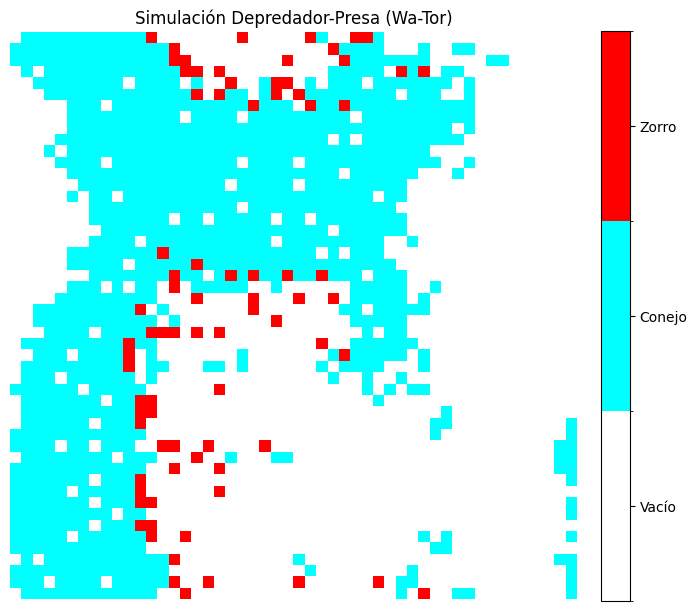

In [8]:
alto=50
ancho=50
# Definición de Estados
ESTADO_VACIO = 0
ESTADO_CONEJO = 1
ESTADO_ZORRO = 2
ESTADO_OBSTACULO = 3


my_cmap = mcolors.ListedColormap(['white', 'cyan', 'red'])
bounds = [0, 1, 2, 3]
norm = mcolors.BoundaryNorm(bounds, my_cmap.N)
grilla, edad, hambre = crear_mapa(alto, ancho)

i=0
while i <100:
    i+=1
    fig, ax = plt.subplots(figsize=(8, 8))

    img = ax.imshow(grilla, cmap=my_cmap, norm=norm, origin='upper', interpolation='nearest')
    ax.set_title("Simulación Depredador-Presa (Wa-Tor)")
    ax.axis('off')

    # Barra de color
    cbar = plt.colorbar(img, ticks=[0.5, 1.5, 2.5], boundaries=bounds, fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels(['Vacío', 'Conejo', 'Zorro'])

    actualizar(grilla, edad, hambre, alto, ancho)
    img.set_data(grilla)
    plt.draw()
    plt.show()
    clear_output(wait=True)


